# Run Verbalization Lens
This notebook lets you run our lens setup for any image for Qwen3-2B and 8B. 

In [1]:
from nnsight import VisionLanguageModel
# model_name = "Qwen3-VL-2B-Instruct"; K=45
model_name = "Qwen3-VL-8B-Instruct"; K=115 
model = VisionLanguageModel(f"Qwen/{model_name}", device_map="cuda", dispatch=True)
processor = model.processor 

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

You can drop in an image of your choosing here!

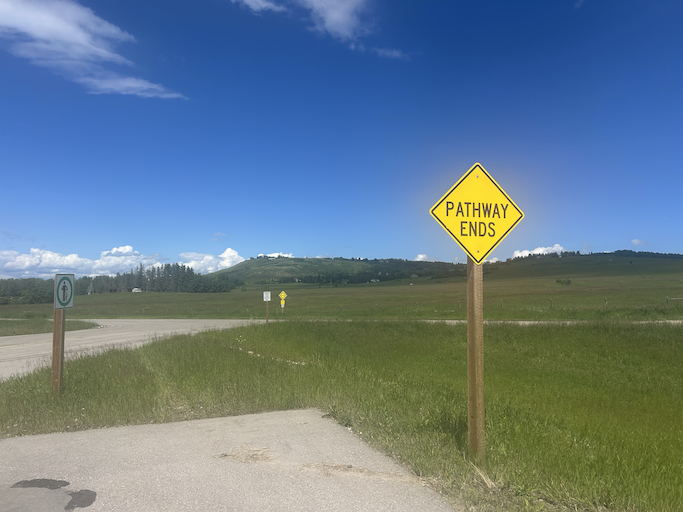

In [2]:
from PIL import Image
img = Image.open("../images/calgary.png") 
img

Now, we'll actually sum together the OV matrices of the top-K heads from score_ocr_heads. 
In this notebook we've hard-coded K, but it's just 10% of the model's total number of heads.

In [3]:
import torch 

def flat_to_grid(flatidx, n_heads=model.model.language_model.config.num_attention_heads):
    return ((flatidx // n_heads).item(), (flatidx % n_heads).item()) # layer, head 

hd = model.model.language_model.config.head_dim
md = model.model.language_model.config.hidden_size
nrepeats = model.config.text_config.num_attention_heads // model.config.text_config.num_key_value_heads 

sum_score, denom = torch.load(f"../results/score_ocr_heads/{model_name}/final_1024.pt")
head_scores = sum_score / denom 

_, idxs = torch.topk(head_scores.view(-1), K)
ocr_heads = [flat_to_grid(idx) for idx in idxs]
ocr_lens = torch.zeros((md, md), device="cuda", dtype=model.dtype)
with torch.no_grad():
    for (l, h) in ocr_heads:
        # (out, in) so select columns of the o_proj matrix 
        O = model.model.language_model.layers[l].self_attn.o_proj.weight[:, h * hd : (h+1) * hd]

        # (out, in) GQA with query=16, kv=8, so model dim becomes halved; two q for every kv
        # so (1024, 2048) we have to reshape to be (8, 128, 2048) and repeat_interleave along dim=0
        Vfull = torch.repeat_interleave(
            model.model.language_model.layers[l].self_attn.v_proj.weight.view(-1, hd, md), 
            repeats=nrepeats, dim=0
        ) # (16, 128, 2048)
        assert torch.allclose(Vfull[0], Vfull[1])
        V = Vfull[h]

        ocr_lens += O @ V

In [4]:
# function to cache hidden states for image 
def get_img_states(model, prompt, prefill, processor, img=None):
    messages = [{
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": prompt},
        ],
    }]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    text = text + prefill 

    if img is not None:
        inputs = processor(text=[text], images=[img], return_tensors="pt").to("cuda")
    else:
        inputs = processor(text=[text], return_tensors="pt").to("cuda")

    img_pad_token_id = processor.tokenizer.convert_tokens_to_ids("<|image_pad|>")
    img_pad_positions = (inputs["input_ids"][0] == img_pad_token_id).nonzero(as_tuple=True)[0]
    
    with torch.no_grad():
        all_states = []
        for layer in range(len(model.model.language_model.layers)):
            with model.trace(**inputs):
                all_states.append(
                    model.model.language_model.layers[layer].output[0, img_pad_positions].save()
                )

        return torch.stack(all_states), inputs

In [5]:
# now actually cache the hidden states for our image
prompt, prefill = "", "" # doesn't matter, it's after image 
states, inputs = get_img_states(model, prompt, prefill, processor, img)

These functions are unused, but just for reference if you don't want the whole widget setup. 
We're just printing out the top predictions from either raw logit lens or our verbalization lens.

In [6]:
# vanilla/"raw" logit lens (nostalgebraist)
def ll(state):
    probs = model.lm_head(model.model.language_model.norm(state)).softmax(dim=-1)
    vals, toks = torch.topk(probs, k=5)
    out_str = ""
    for t, v in zip(toks, vals):
        out_str += repr(model.tokenizer.decode(t)) + '\t' + str(round(v.item(), 3))
        out_str += '\n'
    return out_str

# our verbalization lens 
def verb_ll(state, ocr_lens=ocr_lens):
    with torch.no_grad():
        state = ocr_lens @ state
        probs = model.lm_head(model.model.language_model.norm(state)).softmax(dim=-1)
        vals, toks = torch.topk(probs, k=5)
        out_str = ""
        for t, v in zip(toks, vals):
            out_str += repr(model.tokenizer.decode(t)) + '\t' + str(round(v.item(), 3))
            out_str += '\n'
    return out_str

In [7]:
print("Raw logit lens on first state:")
print(ll(states[0, 0]))
print("Verbalization lens on first state:")
print(verb_ll(states[0, 0]))

Raw logit lens on first state:
'퀴'	0.173
'iesz'	0.06
'cé'	0.046
'ritch'	0.021
'rieg'	0.018

Verbalization lens on first state:
'口岸'	0.248
'畜'	0.091
'大战'	0.081
'强奸'	0.055
'獒'	0.049



# Interactive widget
Courtesy of Claude, this lets you click on specific image tokens and compare verbalization lens to raw logit lens outputs.

Note: if clicking on the widget isn't working, if you're using VS Code, you can add this line to your local user settings: `"jupyter.widgetScriptSources": ["jsdelivr.com", "unpkg.com"]`. Then reload/restart, and re-run the notebook.

In [8]:
import io
import html as _html
import traceback
import ipywidgets as widgets
from ipyevents import Event
from PIL import Image, ImageDraw

# ---- grid geometry -------------------------------------------------------
t, h, w = inputs["image_grid_thw"][0].tolist()
merge = processor.image_processor.merge_size
grid_h, grid_w = h // merge, w // merge
orig_w, orig_h = img.size

# image-token block start, so we can also report the absolute position
img_pad_id = processor.tokenizer.convert_tokens_to_ids("<|image_pad|>")
img_positions = (inputs["input_ids"][0] == img_pad_id).nonzero(as_tuple=True)[0].tolist()
img_start = min(img_positions)

STEP = 2      # show every Nth layer
TOPK = 4      # tokens per lens


def _pil_to_png_bytes(im):
    buf = io.BytesIO()
    im.convert("RGB").save(buf, format="PNG")
    return buf.getvalue()


def _render_with_cell(row, col, alpha=0.4):
    cell_w, cell_h = orig_w / grid_w, orig_h / grid_h
    x0, y0 = col * cell_w, row * cell_h
    x1, y1 = (col + 1) * cell_w, (row + 1) * cell_h
    out = img.convert("RGBA").copy()
    overlay = Image.new("RGBA", out.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)
    draw.rectangle([x0, y0, x1, y1], fill=(255, 0, 0, int(255 * alpha)),
                   outline=(255, 0, 0, 255), width=3)
    return Image.alpha_composite(out, overlay)


def _chip(tok, prob):
    """A single token chip, shaded by probability."""
    shade = int(255 - 135 * min(prob, 1.0))          # higher prob -> darker blue
    bg = f"rgb({shade},{shade},255)"
    label = _html.escape(repr(tok))
    return (f'<span style="display:inline-block;margin:1px;padding:1px 5px;'
            f'border-radius:4px;background:{bg};font-family:monospace;'
            f'font-size:11px;white-space:nowrap;">{label} '
            f'<b>{prob:.2f}</b></span>')


def _lens_cells(state):
    """Return (vanilla_html, ocr_html) chip strings for one hidden state."""
    with torch.no_grad():
        v_probs = model.lm_head(model.model.language_model.norm(state)).softmax(-1)
        v_vals, v_toks = v_probs.topk(TOPK)
        o_probs = model.lm_head(model.model.language_model.norm(ocr_lens @ state)).softmax(-1)
        o_vals, o_toks = o_probs.topk(TOPK)
    v = "".join(_chip(model.tokenizer.decode(t), p.item()) for t, p in zip(v_toks, v_vals))
    o = "".join(_chip(model.tokenizer.decode(t), p.item()) for t, p in zip(o_toks, o_vals))
    return v, o


def _lens_html(rel_pos):
    rows = [
        '<tr style="position:sticky;top:0;background:#fff;">'
        '<th style="text-align:right;padding:2px 8px;">Layer</th>'
        '<th style="text-align:left;padding:2px 8px;">Verbalization Lens (ours)</th>'
        '<th style="text-align:left;padding:2px 8px;">Logit Lens (baseline)</th></tr>'
    ]
    for layer in range(0, len(states), STEP):
        v, o = _lens_cells(states[layer][rel_pos])
        bg = "#fafafa" if (layer // STEP) % 2 else "#ffffff"
        rows.append(
            f'<tr style="background:{bg};">'
            f'<td style="text-align:right;padding:2px 8px;color:#888;font-family:monospace;">{layer}</td>'
            f'<td style="padding:2px 8px;">{o}</td>'
            f'<td style="padding:2px 8px;border-left:1px solid #eee;">{v}</td></tr>'
        )
    return ('<div style="max-height:620px;overflow-y:auto;border:1px solid #ddd;border-radius:6px;">'
            '<table style="border-collapse:collapse;width:100%;">'
            + "".join(rows) + '</table></div>')


# ---- widgets -------------------------------------------------------------
image_w = widgets.Image(format="png", layout=widgets.Layout(width="380px"))
header_w = widgets.HTML()
result_w = widgets.HTML()
debug_out = widgets.Output(layout=widgets.Layout(
    border="1px solid #ccc", padding="4px", max_height="160px",
    overflow="auto", font_family="monospace",
))

# fixed-width left column so the image can't reflow under the click handler
left = widgets.VBox(
    [widgets.HTML("<b>Click a cell of the image &rarr;</b>"), image_w],
    layout=widgets.Layout(width="400px", flex="0 0 auto"),
)
right = widgets.VBox([header_w, result_w])
ui = widgets.VBox([widgets.HBox([left, right]),
                   widgets.HTML("<b>debug log (click events land here):</b>"),
                   debug_out])

_click_count = 0


def _select(row, col):
    row = max(0, min(grid_h - 1, row))
    col = max(0, min(grid_w - 1, col))
    rel_pos = row * grid_w + col
    image_w.value = _pil_to_png_bytes(_render_with_cell(row, col))
    header_w.value = (
        f'<div style="font-family:monospace;font-size:13px;margin-bottom:4px;">'
        f'using top-{K} heads.   '
        f'cell (row={row}, col={col}) &nbsp;|&nbsp; relative tok {rel_pos} '
        f'&nbsp;|&nbsp; absolute tok {rel_pos + img_start}</div>'
    )
    result_w.value = _lens_html(rel_pos)


def _on_click(event):
    global _click_count
    _click_count += 1
    with debug_out:
        try:
            bw = event.get("boundingRectWidth") or 1
            bh = event.get("boundingRectHeight") or 1
            fx = event["relativeX"] / bw
            fy = event["relativeY"] / bh
            row, col = int(fy * grid_h), int(fx * grid_w)
            print(f"[click #{_click_count}] relX={event.get('relativeX')} relY={event.get('relativeY')} "
                  f"box={bw}x{bh} -> row={row} col={col}")
            _select(row, col)
        except Exception:
            print(f"[click #{_click_count}] ERROR:")
            traceback.print_exc()


click = Event(source=image_w, watched_events=["click"])
click.on_dom_event(_on_click)

_select(grid_h // 2, grid_w // 2)   # initial selection
with debug_out:
    print("cell ran. grid =", grid_h, "x", grid_w,
          "| ipyevents attached. Click the image; each click should log a line below.")
display(ui)
